In [ ]:
# Prediction of Agriculture Crop Yield Using Machine Learning

## Internship Project

### Student Name: Your Name

#### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

### Machine Learning Algorithm
- Random Forest Regressor

In [2]:
import pandas as pd

print("Pandas installed successfully!")

Pandas installed successfully!


In [1]:
import os

files = os.listdir()

print("Files in this folder:")
for file in files:
    print(file)

Files in this folder:
datafile (1).csv
datafile (2).csv
Agriculture_Crop_Production_Prediction.ipynb
datafile.csv
.ipynb_checkpoints
datafile (3).csv
produce.csv


In [2]:
import pandas as pd

df = pd.read_csv("produce.csv")

print(df.head())

                                      Particulars  \
0              Agricultural Production Foodgrains   
1       Agricultural Production Foodgrains Kharif   
2         Agricultural Production Foodgrains Rabi   
3         Agricultural Production Foodgrains Rice   
4  Agricultural Production Foodgrains Rice Kharif   

                         Frequency    Unit   3-1993   3-1994   3-1995  \
0  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
1  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
2  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
3  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
4  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   

    3-1996   3-1997   3-1998   3-1999  ...     3-2005    3-2006     3-2007  \
0      NaN      NaN      NaN      NaN  ...  198.36282  208.6016  217.28212   
1      NaN      NaN      NaN      NaN  ...  103.30942  109.8734  110.57622   
2      N

In [3]:
files = [
    "datafile.csv",
    "datafile (1).csv",
    "datafile (2).csv",
    "datafile (3).csv"
]

for file in files:
    print("=" * 60)
    print("FILE:", file)
    try:
        df = pd.read_csv(file)
        print(df.head())
        print("\nColumns:")
        print(df.columns.tolist())
    except Exception as e:
        print("Error:", e)

FILE: datafile.csv
             Crop  2004-05  2005-06  2006-07  2007-08  2008-09  2009-10  \
0            Rice    100.0    101.0     99.0    105.0    112.0    121.0   
1           Wheat    100.0    101.0    112.0    115.0    117.0    127.0   
2  Coarse Cereals    100.0    107.0    110.0    115.0    113.0    123.0   
3          Pulses    100.0    108.0    134.0    124.0    124.0    146.0   
4     Vegetables     100.0    109.0    103.0    118.0    113.0    124.0   

   2010-11  2011-12  
0    117.0    110.0  
1    120.0    108.0  
2    122.0    136.0  
3    137.0    129.0  
4    128.0    115.0  

Columns:
['Crop', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10', '2010-11', '2011-12']
FILE: datafile (1).csv
    Crop           State  Cost of Cultivation (`/Hectare) A2+FL  \
0  ARHAR   Uttar Pradesh                                9794.05   
1  ARHAR       Karnataka                               10593.15   
2  ARHAR         Gujarat                               13468.82   


In [4]:
import pandas as pd

df = pd.read_csv("datafile (1).csv")

df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     object 
 1   State                                  49 non-null     object 
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.4+ KB


In [6]:
df.isnull().sum()

Crop                                     0
State                                    0
Cost of Cultivation (`/Hectare) A2+FL    0
Cost of Cultivation (`/Hectare) C2       0
Cost of Production (`/Quintal) C2        0
Yield (Quintal/ Hectare)                 0
dtype: int64

In [7]:
df.shape

(49, 6)

In [8]:
df.columns

Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) '],
      dtype='object')

In [9]:
df

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72
5,COTTON,Maharashtra,23711.44,33116.82,2539.47,12.69
6,COTTON,Punjab,29047.10,50828.83,2003.76,24.39
7,COTTON,Andhra Pradesh,29140.77,44756.72,2509.99,17.83
8,COTTON,Gujarat,29616.09,42070.44,2179.26,19.05
9,COTTON,Haryana,29918.97,44018.18,2127.35,19.90


In [10]:
df.describe()

,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


In [11]:
df["Crop"].value_counts()

Crop
ARHAR                   5
COTTON                  5
GRAM                    5
GROUNDNUT               5
MAIZE                   5
MOONG                   5
PADDY                   5
RAPESEED AND MUSTARD    5
SUGARCANE               5
WHEAT                   4
Name: count, dtype: int64

In [12]:
df["State"].value_counts()

State
Andhra Pradesh    8
Uttar Pradesh     7
Maharashtra       6
Karnataka         5
Rajasthan         5
Gujarat           4
Punjab            3
Madhya Pradesh    3
Haryana           2
Tamil Nadu        2
Orissa            2
Bihar             1
West Bengal       1
Name: count, dtype: int64

In [13]:
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()
le_state = LabelEncoder()

df["Crop"] = le_crop.fit_transform(df["Crop"])
df["State"] = le_state.fit_transform(df["State"])

df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,0,11,9794.05,23076.74,1941.55,9.83
1,0,4,10593.15,16528.68,2172.46,7.47
2,0,2,13468.82,19551.90,1898.30,9.59
3,0,0,17051.66,24171.65,3670.54,6.42
4,0,6,17130.55,25270.26,2775.80,8.72


In [14]:
X = df.drop("Yield (Quintal/ Hectare) ", axis=1)
y = df["Yield (Quintal/ Hectare) "]

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Input Features (X):
   Crop  State  Cost of Cultivation (`/Hectare) A2+FL  \
0     0     11                                9794.05   
1     0      4                               10593.15   
2     0      2                               13468.82   
3     0      0                               17051.66   
4     0      6                               17130.55   

   Cost of Cultivation (`/Hectare) C2  Cost of Production (`/Quintal) C2  
0                            23076.74                            1941.55  
1                            16528.68                            2172.46  
2                            19551.90                            1898.30  
3                            24171.65                            3670.54  
4                            25270.26                            2775.80  

Target Variable (y):
0    9.83
1    7.47
2    9.59
3    6.42
4    8.72
Name: Yield (Quintal/ Hectare) , dtype: float64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (39, 5)
Testing Data Shape: (10, 5)


In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[   8.05   23.59   34.99 1015.45   11.98    1.32    4.05    3.01   32.42
    9.33]

Predicted Values:
[  8.8966  49.7925  46.855  797.3447  16.5054   6.3088   7.2594   6.8473
  38.1995  14.3888]


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error (MAE): 28.44
Mean Squared Error (MSE): 4852.74
Root Mean Squared Error (RMSE): 69.66
R² Score: 0.95


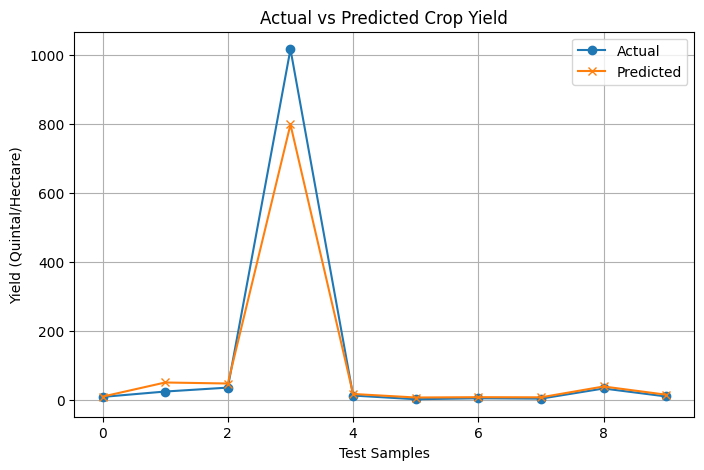

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.title("Actual vs Predicted Crop Yield")
plt.xlabel("Test Samples")
plt.ylabel("Yield (Quintal/Hectare)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

print("Model Comparison")
print("-" * 40)

for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    score = r2_score(y_test, prediction)
    print(f"{name}: {score:.4f}")

Model Comparison
----------------------------------------
Linear Regression: 0.7800
Decision Tree: 0.6444
Random Forest: 0.9463


In [21]:
import joblib

joblib.dump(model, "crop_yield_model.pkl")

print("Model saved successfully!")

Model saved successfully!


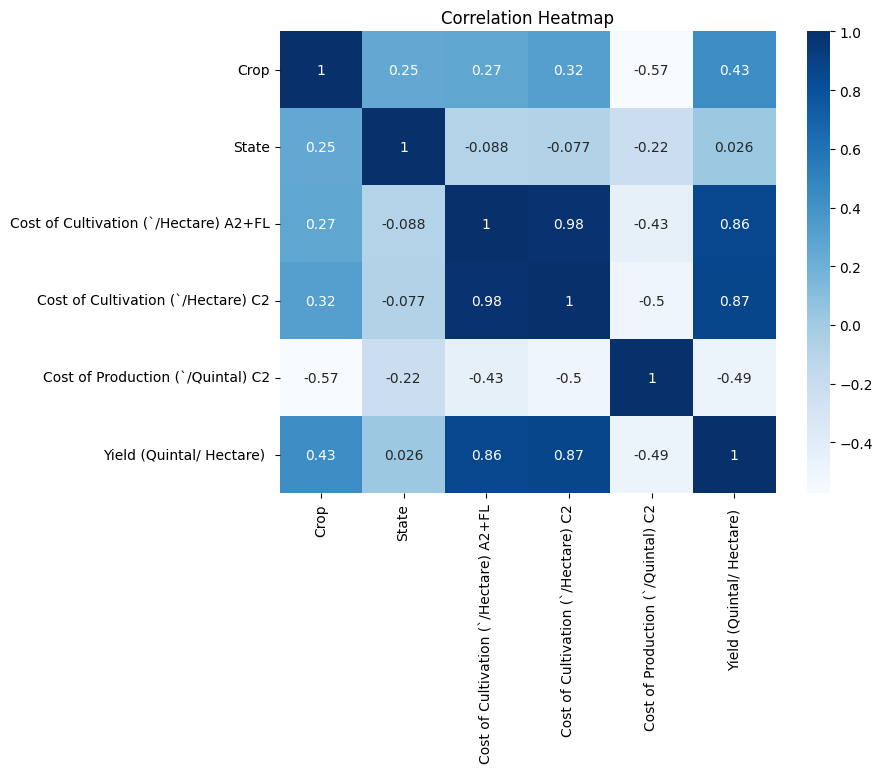

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

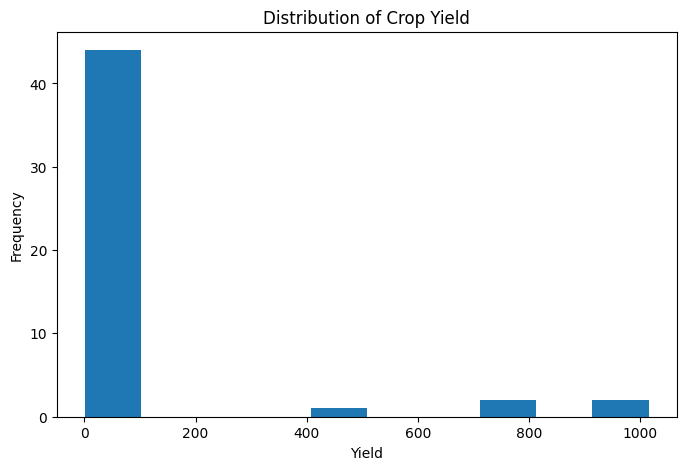

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df["Yield (Quintal/ Hectare) "], bins=10)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

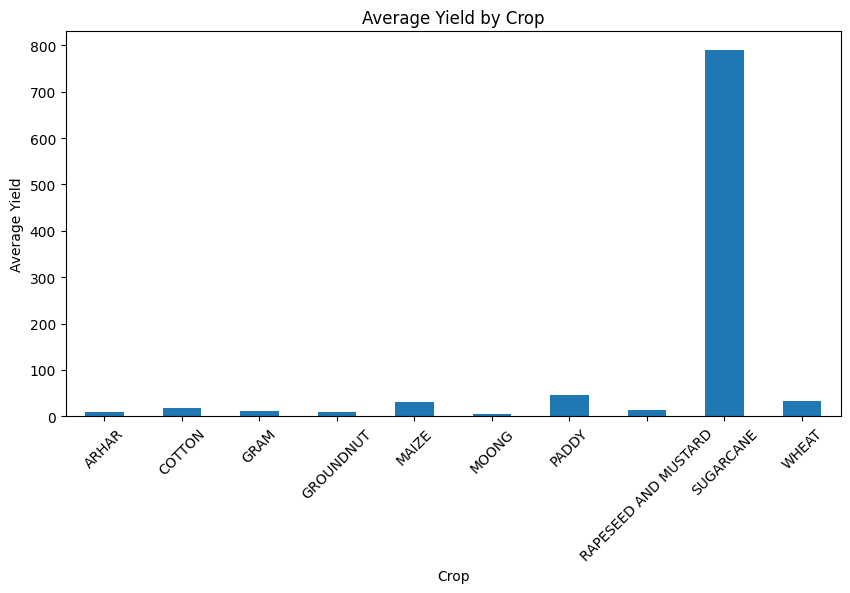

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload original data to get crop names
original_df = pd.read_csv("datafile (1).csv")

crop_yield = original_df.groupby("Crop")["Yield (Quintal/ Hectare) "].mean()

plt.figure(figsize=(10,5))
crop_yield.plot(kind="bar")
plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Conclusion

This project predicts crop yield using Machine Learning techniques.

The dataset was preprocessed by checking missing values, encoding categorical variables, and selecting relevant features.

A Random Forest Regressor was trained to predict crop yield.

The model achieved an R² Score of approximately 0.95, indicating excellent predictive performance on the available dataset.

This project demonstrates how Machine Learning can assist in agricultural decision-making by estimating crop yield based on cultivation costs and other factors.